In [22]:

# SECTION 0: IMPORTS & CONFIGURATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from pathlib import Path
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

warnings.filterwarnings("ignore")

# ── Global Plot Style ──────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
})

# Color palette — binary focus first
PALETTE_BINARY = {0: "#2ecc71", 1: "#e74c3c"}
LABEL_MAP      = {0: "Low Risk", 1: "High Risk"}
COLORS         = ["#2ecc71", "#e74c3c"]

# Paths
PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "synthetic_gambling_data.csv"
FIGURES_DIR  = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Imports complete")
print(f"Figures → {FIGURES_DIR}")

Imports complete
Figures → /workspaces/Gambling-ML-/figures


In [23]:
# SECTION 1: LOAD RAW DATA
df_raw = pd.read_csv(DATASET_PATH)
df_raw.info()
df_raw.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 56 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   player_id                            6000 non-null   int64  
 1   signup_date                          6000 non-null   str    
 2   age                                  5699 non-null   float64
 3   primary_product_type                 6000 non-null   str    
 4   synthetic_income_monthly             5678 non-null   float64
 5   debt_to_income_ratio                 5704 non-null   float64
 6   synthetic_credit_score               5699 non-null   float64
 7   risk_profile                         6000 non-null   int64  
 8   data_year                            6000 non-null   int64  
 9   account_tenure_days                  5685 non-null   float64
 10  credit_score_velocity_7d             5690 non-null   float64
 11  liquid_savings_balance               5721

,player_id,age,synthetic_income_monthly,debt_to_income_ratio,synthetic_credit_score,risk_profile,data_year,account_tenure_days,credit_score_velocity_7d,liquid_savings_balance,...,bonus_sensitivity_index,push_notification_density,gambling_ad_ctr,vip_status,limit_setting_flag,deposit_limit_breach_attempts,time_out_requests_count,responsible_gambling_message_count,regulatory_friction_score,friction_bypass_attempt_flag
count,6000.00000,5699.000000,5678.000000,5704.000000,5699.000000,6000.000000,6000.000000,5685.000000,5690.000000,5721.000000,...,5713.000000,5715.000000,5720.000000,5708.000000,5732.000000,5690.000000,5706.000000,5682.000000,5702.000000,5701.000000
mean,100499.50000,43.256010,4837.422482,0.748671,567.945078,0.500000,2022.500000,1642.180475,-13.213005,24611.147672,...,0.346651,14.942782,0.075325,0.074632,0.508374,1.353076,0.345075,3.481345,0.202549,0.039818
std,288.69905,15.120143,1972.227550,0.436682,156.145964,0.670876,1.707967,657.682121,12.144352,12417.899226,...,0.195866,5.878455,0.051638,0.262820,0.499973,2.046810,0.682516,2.480216,0.156722,0.195548
min,100000.00000,18.000000,1000.000000,0.000963,300.000000,0.000000,2020.000000,366.000000,-40.000000,3015.418523,...,0.000031,5.000000,0.005389,0.000000,0.000000,0.000000,0.000000,0.000000,0.000028,0.000000
25%,100249.75000,30.000000,3465.565863,0.368737,433.000000,0.000000,2021.000000,1093.000000,-24.000000,14117.706918,...,0.203598,11.000000,0.037735,0.000000,0.000000,0.000000,0.000000,1.000000,0.087230,0.000000
50%,100499.50000,43.000000,4932.793120,0.760873,564.000000,0.000000,2022.500000,1645.000000,-13.000000,23958.882683,...,0.338545,15.000000,0.065271,0.000000,1.000000,0.000000,0.000000,3.000000,0.176357,0.000000
75%,100749.25000,57.000000,6163.700879,1.120098,701.500000,1.000000,2024.000000,2187.000000,-3.000000,34552.508638,...,0.470035,19.000000,0.096970,0.000000,1.000000,2.000000,1.000000,5.000000,0.277105,0.000000
max,100999.00000,73.000000,10828.489297,1.499113,849.000000,2.000000,2025.000000,2918.000000,9.000000,49994.350117,...,0.897645,31.000000,0.374734,1.000000,1.000000,13.000000,5.000000,10.000000,1.153901,1.000000


In [24]:
missing_summary = (
    df_raw.isna()
      .sum()
      .sort_values(ascending=False)
      .rename("missing_count")
      .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df_raw) * 100).round(2)
missing_summary

,missing_count,missing_pct
avg_session_duration_minutes,338,5.63
parlay_ratio,338,5.63
chase_magnitude_index,337,5.62
synthetic_income_monthly,322,5.37
deposit_count_30d,320,5.33
responsible_gambling_message_count,318,5.30
account_tenure_days,315,5.25
avg_bets_per_active_day,313,5.22
avg_deposit_size,312,5.20
bank_decline_count_7d,312,5.20


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Load & Setup
df_raw = pd.read_csv(DATASET_PATH)
TARGET = "risk_profile"
ID_DATE_META = ["player_id", "data_year", "signup_date"]
CAT_COLS = [
    "primary_product_type", "affiliate_referral_source",
    "vip_status", "limit_setting_flag", "same_day_multiple_session_flag", 
    "friction_bypass_attempt_flag"
]
NUM_COLS = [c for c in df_raw.columns if c not in CAT_COLS + ID_DATE_META + [TARGET]]
LABEL_MAP = {0: "Low", 1: "Medium", 2: "High"}
COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]

print(f"📊 Loaded: {len(df_raw):,} rows × {len(df_raw.columns)} cols")

📊 Loaded: 6,000 rows × 56 cols


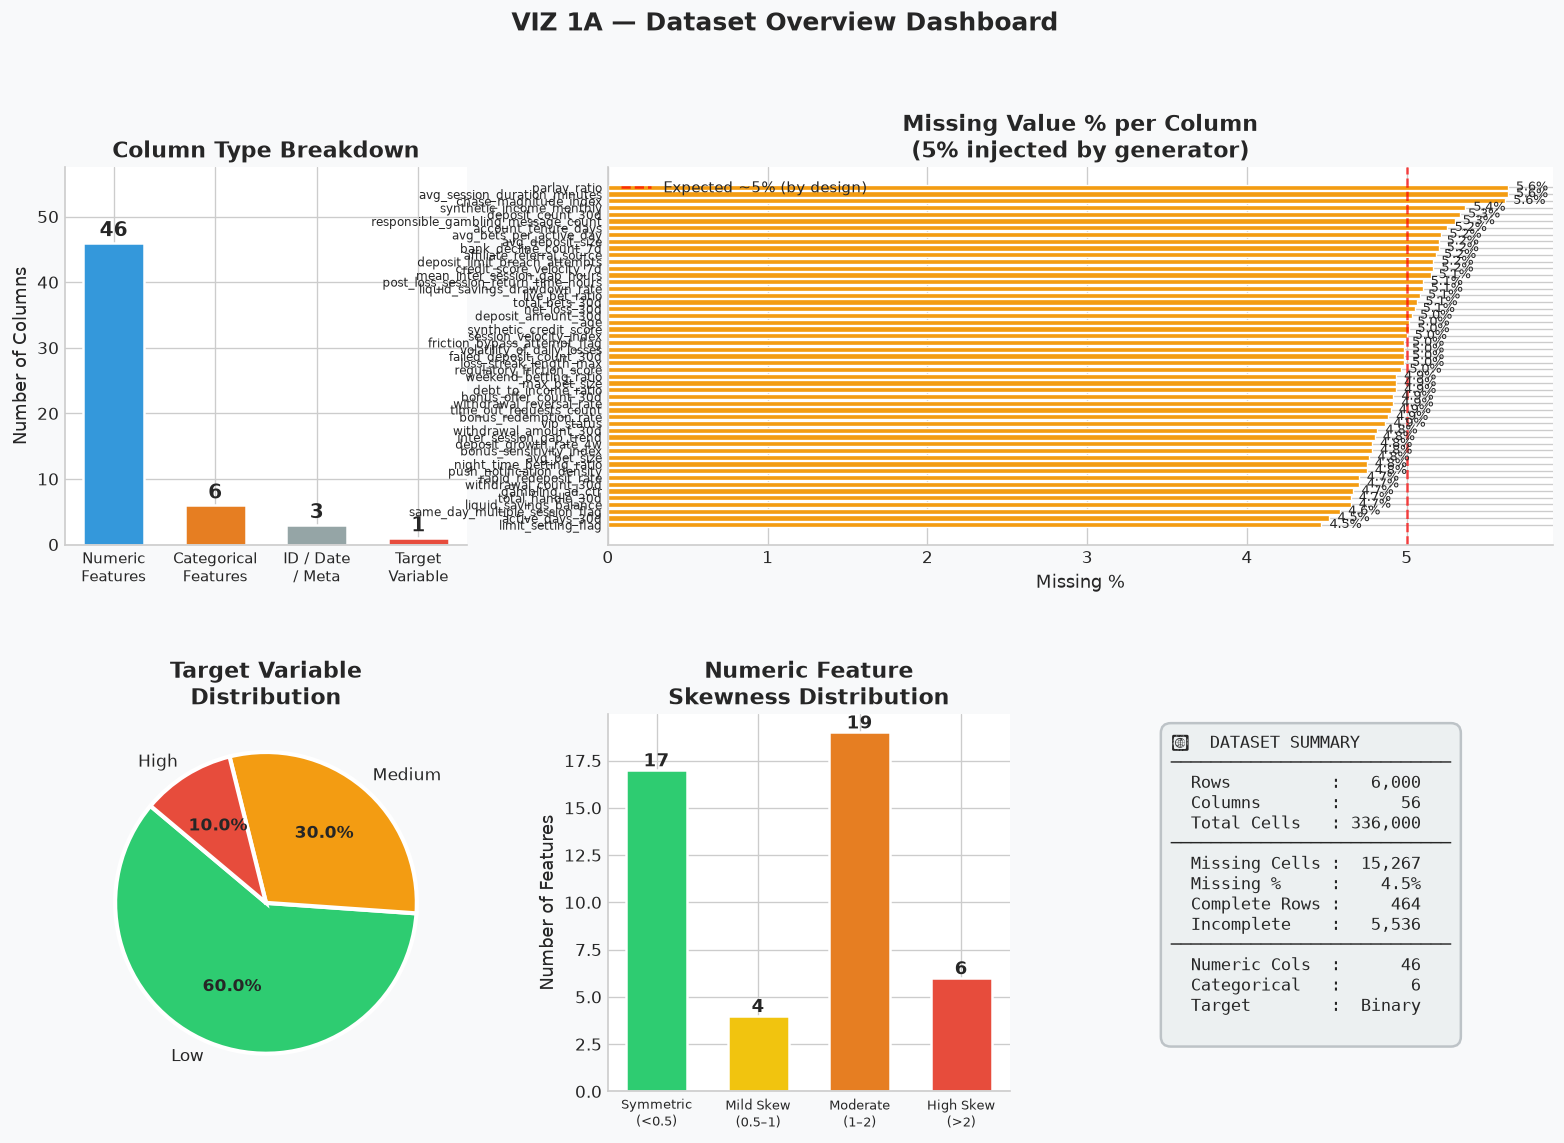

✅ VIZ 1A saved


In [26]:

# VIZ 1A: Dataset Overview Dashboard

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor("#f8f9fa")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Column type breakdown ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

CAT_COLS = [
    "primary_product_type", "affiliate_referral_source",
    "vip_status", "limit_setting_flag",
    "same_day_multiple_session_flag", "friction_bypass_attempt_flag",
]

# Define the target variable
TARGET = "risk_profile"


NUM_COLS = [
    c for c in df_raw.columns
    if c not in CAT_COLS + ID_DATE_META + [TARGET]
]

type_counts = {
    "Numeric\nFeatures"      : len(NUM_COLS),
    "Categorical\nFeatures"  : len(CAT_COLS),
    "ID / Date\n/ Meta"      : len(ID_DATE_META),
    "Target\nVariable"       : 1,
}
bar_colors = ["#3498db", "#e67e22", "#95a5a6", "#e74c3c"]
bars = ax1.bar(
    type_counts.keys(), type_counts.values(),
    color=bar_colors, edgecolor="white", linewidth=1.5, width=0.6
)
for bar, val in zip(bars, type_counts.values()):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(val), ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )
ax1.set_title("Column Type Breakdown")
ax1.set_ylabel("Number of Columns")
ax1.set_ylim(0, max(type_counts.values()) * 1.25)
ax1.tick_params(axis="x", labelsize=9)

# ── Panel 2: Missing values per column ────────────────────
ax2 = fig.add_subplot(gs[0, 1:])

missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df_raw) * 100)

colors_miss = [
    "#e74c3c" if p > 7 else "#f39c12" if p > 4 else "#2ecc71"
    for p in missing_pct
]
bars2 = ax2.barh(
    missing.index, missing_pct.values,
    color=colors_miss, edgecolor="white", linewidth=0.8
)
for bar, val in zip(bars2, missing_pct.values):
    ax2.text(
        val + 0.05, bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%", va="center", fontsize=7.5
    )
ax2.axvline(5, color="red", linestyle="--", linewidth=1.5,
            alpha=0.7, label="Expected ~5% (by design)")
ax2.set_title("Missing Value % per Column\n(5% injected by generator)")
ax2.set_xlabel("Missing %")
ax2.legend(fontsize=9)
ax2.tick_params(axis="y", labelsize=7)

# ── Panel 3: Target distribution ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])

target_counts = df_raw[TARGET].value_counts().sort_index()
wedges, texts, autotexts = ax3.pie(
    target_counts.values,
    labels=[LABEL_MAP[i] for i in target_counts.index],
    colors=COLORS,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2.5},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
ax3.set_title("Target Variable\nDistribution")

# ── Panel 4: Numeric column stats summary ─────────────────
ax4 = fig.add_subplot(gs[1, 1])

skewness = df_raw[NUM_COLS].skew().abs()
skew_bins = pd.cut(
    skewness,
    bins=[-np.inf, 0.5, 1.0, 2.0, np.inf],
    labels=["Symmetric\n(<0.5)", "Mild Skew\n(0.5–1)", 
            "Moderate\n(1–2)", "High Skew\n(>2)"]
)
skew_counts = skew_bins.value_counts().sort_index()
ax4.bar(
    skew_counts.index, skew_counts.values,
    color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"],
    edgecolor="white", linewidth=1.5, width=0.6
)
for i, val in enumerate(skew_counts.values):
    ax4.text(i, val + 0.2, str(val), ha="center",
             fontsize=11, fontweight="bold")
ax4.set_title("Numeric Feature\nSkewness Distribution")
ax4.set_ylabel("Number of Features")
ax4.tick_params(axis="x", labelsize=8)

# ── Panel 5: Dataset size summary text ────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")

total_cells  = df_raw.shape[0] * df_raw.shape[1]
missing_cells= df_raw.isna().sum().sum()
complete_rows= df_raw.dropna().shape[0]

summary_text = (
    f"📊  DATASET SUMMARY\n"
    f"{'─'*28}\n"
    f"  Rows          : {df_raw.shape[0]:>7,}\n"
    f"  Columns       : {df_raw.shape[1]:>7,}\n"
    f"  Total Cells   : {total_cells:>7,}\n"
    f"{'─'*28}\n"
    f"  Missing Cells : {missing_cells:>7,}\n"
    f"  Missing %     : {missing_cells/total_cells*100:>6.1f}%\n"
    f"  Complete Rows : {complete_rows:>7,}\n"
    f"  Incomplete    : {df_raw.shape[0]-complete_rows:>7,}\n"
    f"{'─'*28}\n"
    f"  Numeric Cols  : {len(NUM_COLS):>7,}\n"
    f"  Categorical   : {len(CAT_COLS):>7,}\n"
    f"  Target        : {'Binary':>7}\n"
)
ax5.text(
    0.05, 0.95, summary_text,
    transform=ax5.transAxes,
    fontsize=10, verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1",
              edgecolor="#bdc3c7", linewidth=1.5)
)

plt.suptitle(
    "VIZ 1A — Dataset Overview Dashboard",
    fontsize=15, fontweight="bold", y=1.01
)
plt.savefig(FIGURES_DIR / "VIZ_1A_dataset_overview.png", bbox_inches="tight")
plt.show()
print("✅ VIZ 1A saved")

BEGIN CLEANING 

In [27]:

#Missing value 

print("\n STEP 1: IMPUTATION")
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

df_clean = df_raw.copy()
df_clean[NUM_COLS] = pd.DataFrame(
    imputer_num.fit_transform(df_clean[NUM_COLS]), columns=NUM_COLS, index=df_clean.index
)
df_clean[CAT_COLS] = pd.DataFrame(
    imputer_cat.fit_transform(df_clean[CAT_COLS]), columns=CAT_COLS, index=df_clean.index
)
print(f"Missing values: {df_clean[NUM_COLS].isna().sum().sum()} (was {df_raw[NUM_COLS].isna().sum().sum()})")



 STEP 1: IMPUTATION
Missing values: 0 (was 13822)


In [28]:

print("\n STEP 2: OUTLIERS")
Q1 = df_clean[NUM_COLS].quantile(0.25)
Q3 = df_clean[NUM_COLS].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
df_clean[NUM_COLS] = df_clean[NUM_COLS].clip(lower=lower, upper=upper, axis=1)
print("Outliers capped")


 STEP 2: OUTLIERS
Outliers capped


In [29]:
print("\n STEP 3: SCALING")
scaler = StandardScaler()
df_scaled = df_clean.copy()
df_scaled[NUM_COLS] = pd.DataFrame(
    scaler.fit_transform(df_scaled[NUM_COLS]), columns=NUM_COLS, index=df_scaled.index
)
print(" Features scaled")


 STEP 3: SCALING
 Features scaled


In [30]:
#split 

print("\n STEP 4: TIME-BASED SPLIT")
print("   TRAIN: 2020-2024 | TEST: 2025")

# Split by time
train_data = df_scaled[df_scaled['data_year'] < 2025]
test_data = df_scaled[df_scaled['data_year'] == 2025]

# Features
FEATURES = NUM_COLS + CAT_COLS
X_train = train_data[FEATURES]
X_test = test_data[FEATURES]
y_train = train_data[TARGET]
y_test = test_data[TARGET]

# Encode categoricals
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    le_dict[col] = le

print(f" TRAIN: {X_train.shape} | TEST: {X_test.shape}")
print(f"Target balance - Train: {np.bincount(y_train)} | Test: {np.bincount(y_test)}")


 STEP 4: TIME-BASED SPLIT
   TRAIN: 2020-2024 | TEST: 2025
 TRAIN: (5000, 52) | TEST: (1000, 52)
Target balance - Train: [3000 1500  500] | Test: [600 300 100]


In [31]:
#train model and get variable importance
print("\n STEP 5: BASELINE MODEL")
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=LABEL_MAP.values()))


 STEP 5: BASELINE MODEL


              precision    recall  f1-score   support

         Low       0.91      0.91      0.91       600
      Medium       0.82      0.84      0.83       300
        High       0.83      0.77      0.80       100

    accuracy                           0.87      1000
   macro avg       0.85      0.84      0.85      1000
weighted avg       0.87      0.87      0.87      1000



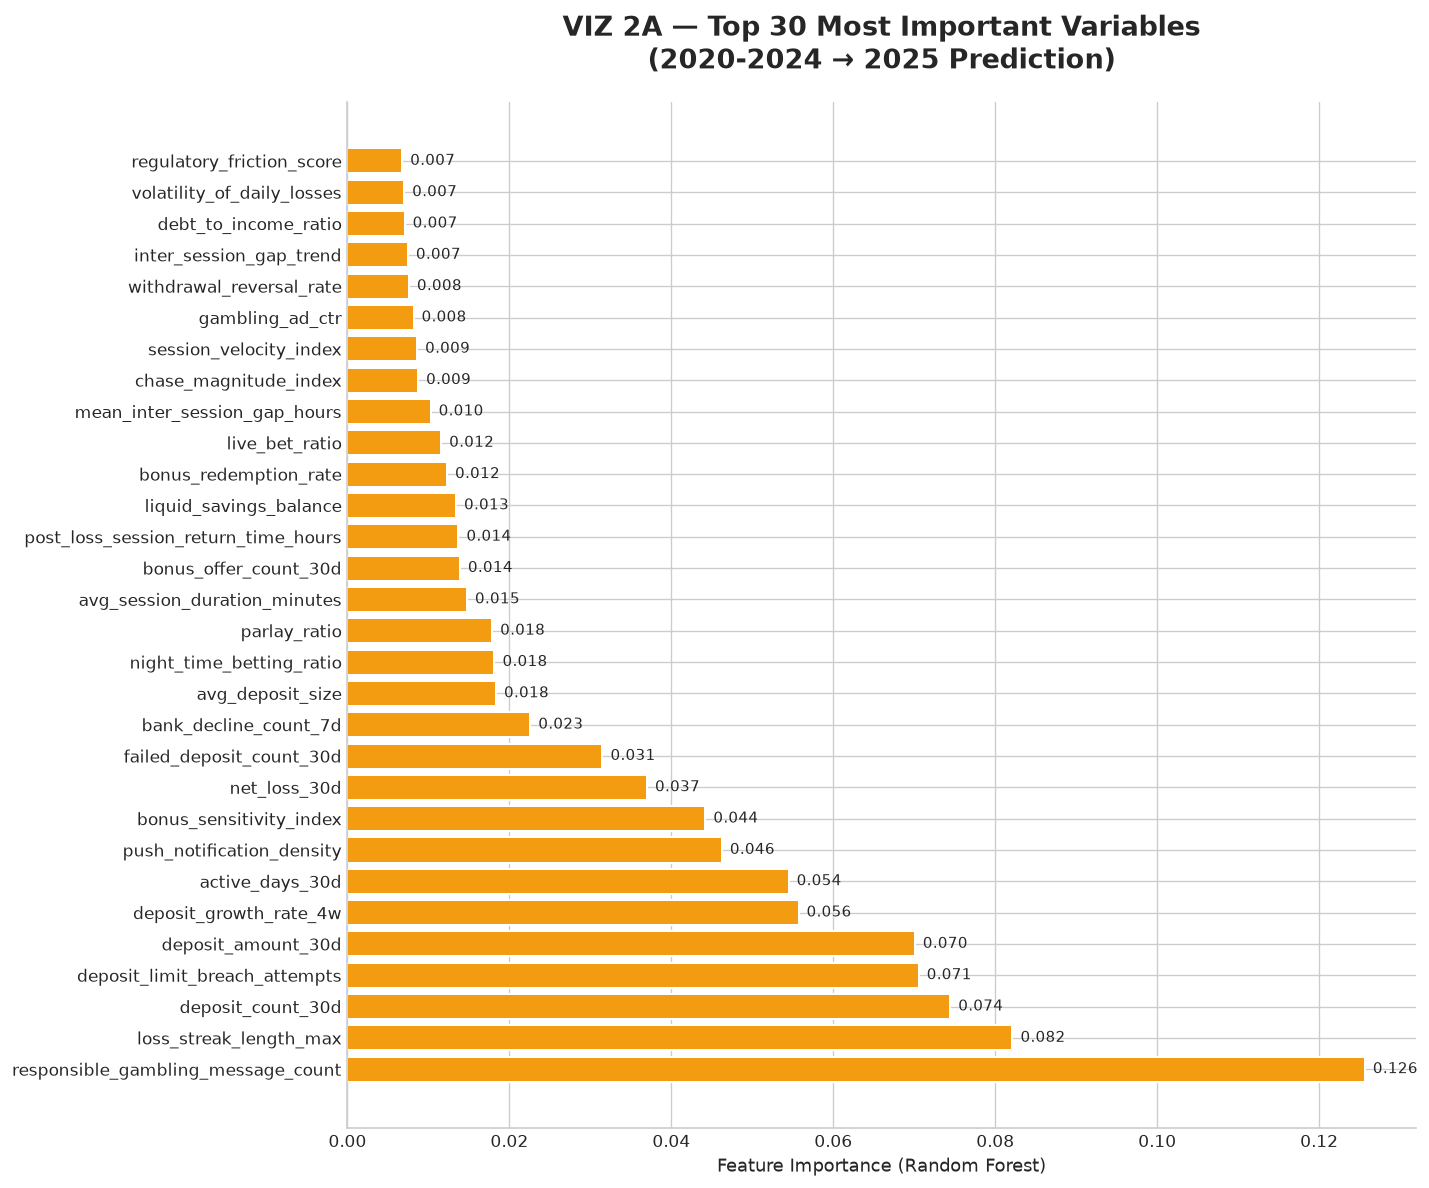

 VIZ 2A: Variable Importance saved

TOP 5 MOST IMPORTANT FEATURES:
['deposit_amount_30d', 'deposit_limit_breach_attempts', 'deposit_count_30d', 'loss_streak_length_max', 'responsible_gambling_message_count']


In [32]:
#visuliaze variable importance 
# VIZ 2A: Variable Importance
importances = pd.DataFrame({
    'feature': FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(30)

plt.figure(figsize=(12, 10))
bars = plt.barh(range(len(importances)), importances['importance'], 
                color=COLORS[1], edgecolor='white', linewidth=1.2)
plt.yticks(range(len(importances)), importances['feature'])
plt.xlabel('Feature Importance (Random Forest)')
plt.title('VIZ 2A — Top 30 Most Important Variables\n(2020-2024 → 2025 Prediction)', 
          fontsize=16, fontweight='bold', pad=20)

# Add value labels
for i, (idx, row) in enumerate(importances.iterrows()):
    plt.text(row['importance'] + 0.001, i, f'{row["importance"]:.3f}', 
             va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_2A_variable_importance.png", dpi=300, bbox_inches='tight')
plt.show()
print(" VIZ 2A: Variable Importance saved")
print("\nTOP 5 MOST IMPORTANT FEATURES:")
print(importances.tail().feature.tolist())

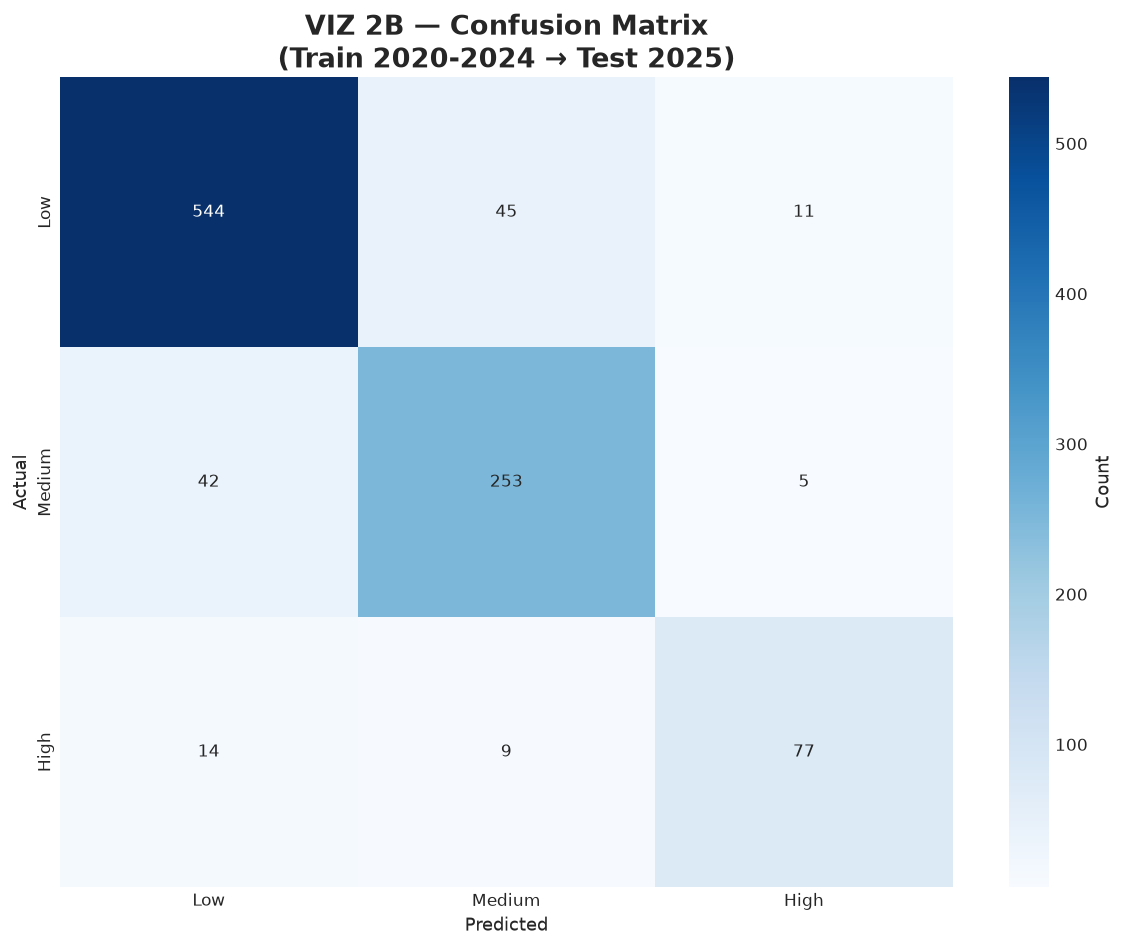

 VIZ 2B: Confusion Matrix saved


In [33]:
# VIZ 2B: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[LABEL_MAP[i] for i in range(3)],
            yticklabels=[LABEL_MAP[i] for i in range(3)],
            cbar_kws={'label': 'Count'})
plt.title('VIZ 2B — Confusion Matrix\n(Train 2020-2024 → Test 2025)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_2B_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print(" VIZ 2B: Confusion Matrix saved")

In [34]:

from pathlib import Path
import pip
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except XGBoostError as e:
    print("XGBoostError:", e)
    print("Please ensure OpenMP runtime is installed. For Mac OSX, run `brew install libomp`.")
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_recall_fscore_support)
from sklearn.model_selection import cross_val_score
import warnings
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

# Setup
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

# Assuming you have: X_train, X_test, y_train, y_test from previous pipeline
# And FEATURES, LABEL_MAP, COLORS defined

LABEL_MAP = {0: "Low", 1: "Medium", 2: "High"}
COLORS = ["#2ecc71", "#f39c12", "#e74c3c"]

In [35]:
print(" TRAINING 5 MODELS FOR 2026 RISK PREDICTION")
print("Train: 2020-2024 | Test: 2025 → Predict: 2026")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, max_depth=6, eval_metric='mlogloss'),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred
    }
    
    print(f"   Accuracy: {accuracy:.3f} | F1: {f1:.3f}")

print("\n All models trained!")

 TRAINING 5 MODELS FOR 2026 RISK PREDICTION
Train: 2020-2024 | Test: 2025 → Predict: 2026
Training Logistic Regression...


   Accuracy: 0.846 | F1: 0.844
Training Decision Tree...
   Accuracy: 0.850 | F1: 0.847
Training Random Forest...
   Accuracy: 0.872 | F1: 0.872
Training XGBoost...
   Accuracy: 0.871 | F1: 0.871

 All models trained!


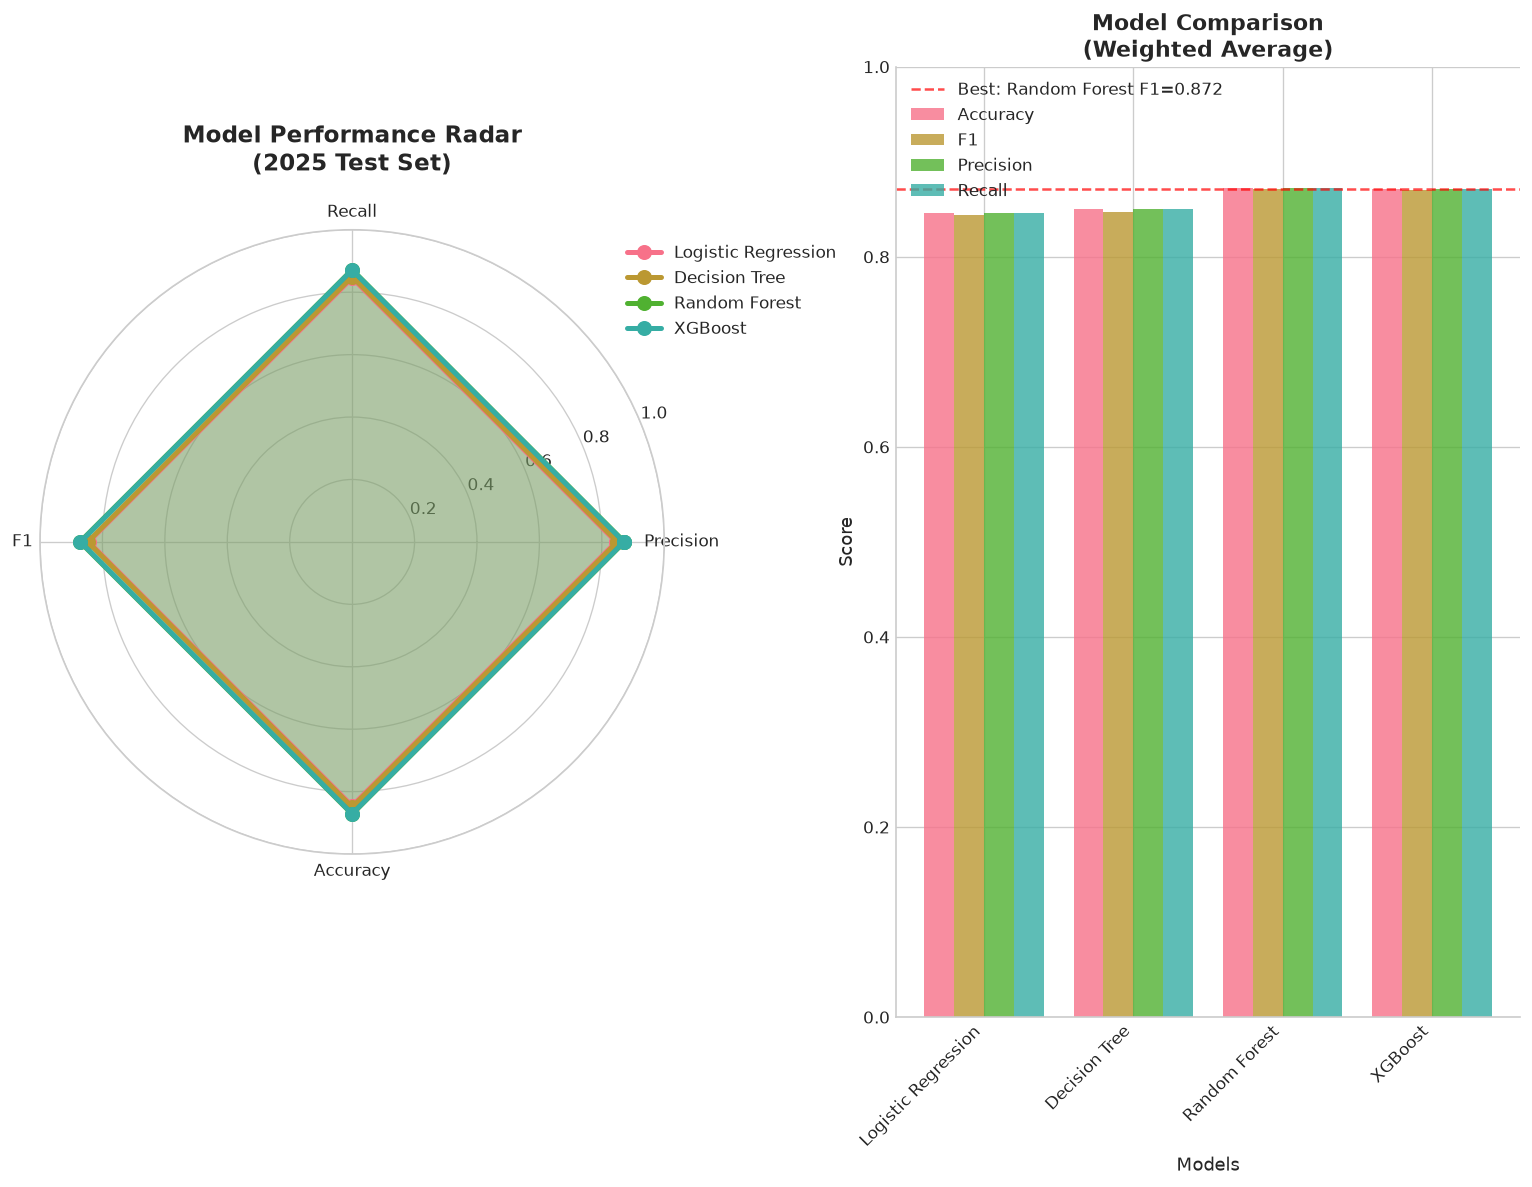

In [36]:
# VIZ 1: Model Performance Radar + Bar Chart
fig = plt.figure(figsize=(20, 10))

# Radar Chart (F1, Precision, Recall, Accuracy)
ax1 = plt.subplot(1, 3, 1, projection='polar')
angles = np.linspace(0, 2*np.pi, 4, endpoint=False).tolist()
angles += angles[:1]  # Complete circle

for i, (name, res) in enumerate(results.items()):
    values = [res['precision'], res['recall'], res['f1'], res['accuracy']]
    values += values[:1]
    ax1.plot(angles, values, 'o-', linewidth=3, label=name, markersize=8)
    ax1.fill(angles, values, alpha=0.2)
    
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(['Precision', 'Recall', 'F1', 'Accuracy'])
ax1.set_ylim(0, 1)
ax1.set_title("Model Performance Radar\n(2025 Test Set)", fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# Bar Chart Comparison
ax2 = plt.subplot(1, 3, 2)
metrics_df = pd.DataFrame(results).T[['accuracy', 'f1', 'precision', 'recall']]
x = np.arange(len(metrics_df))
width = 0.2

for i, metric in enumerate(['accuracy', 'f1', 'precision', 'recall']):
    ax2.bar(x + i*width, metrics_df[metric], width, 
            label=metric.replace('accuracy', 'Accuracy').title(), alpha=0.8)
    
ax2.set_xlabel('Models')
ax2.set_ylabel('Score')
ax2.set_title('Model Comparison\n(Weighted Average)', fontweight='bold')
ax2.set_xticks(x + width*1.5)
ax2.set_xticklabels(metrics_df.index, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 1)

# Best Model Highlight
best_model = max(results.keys(), key=lambda k: results[k]['f1'])
ax2.axhline(y=results[best_model]['f1'], color='red', linestyle='--', 
            alpha=0.7, label=f'Best: {best_model} F1={results[best_model]["f1"]:.3f}')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

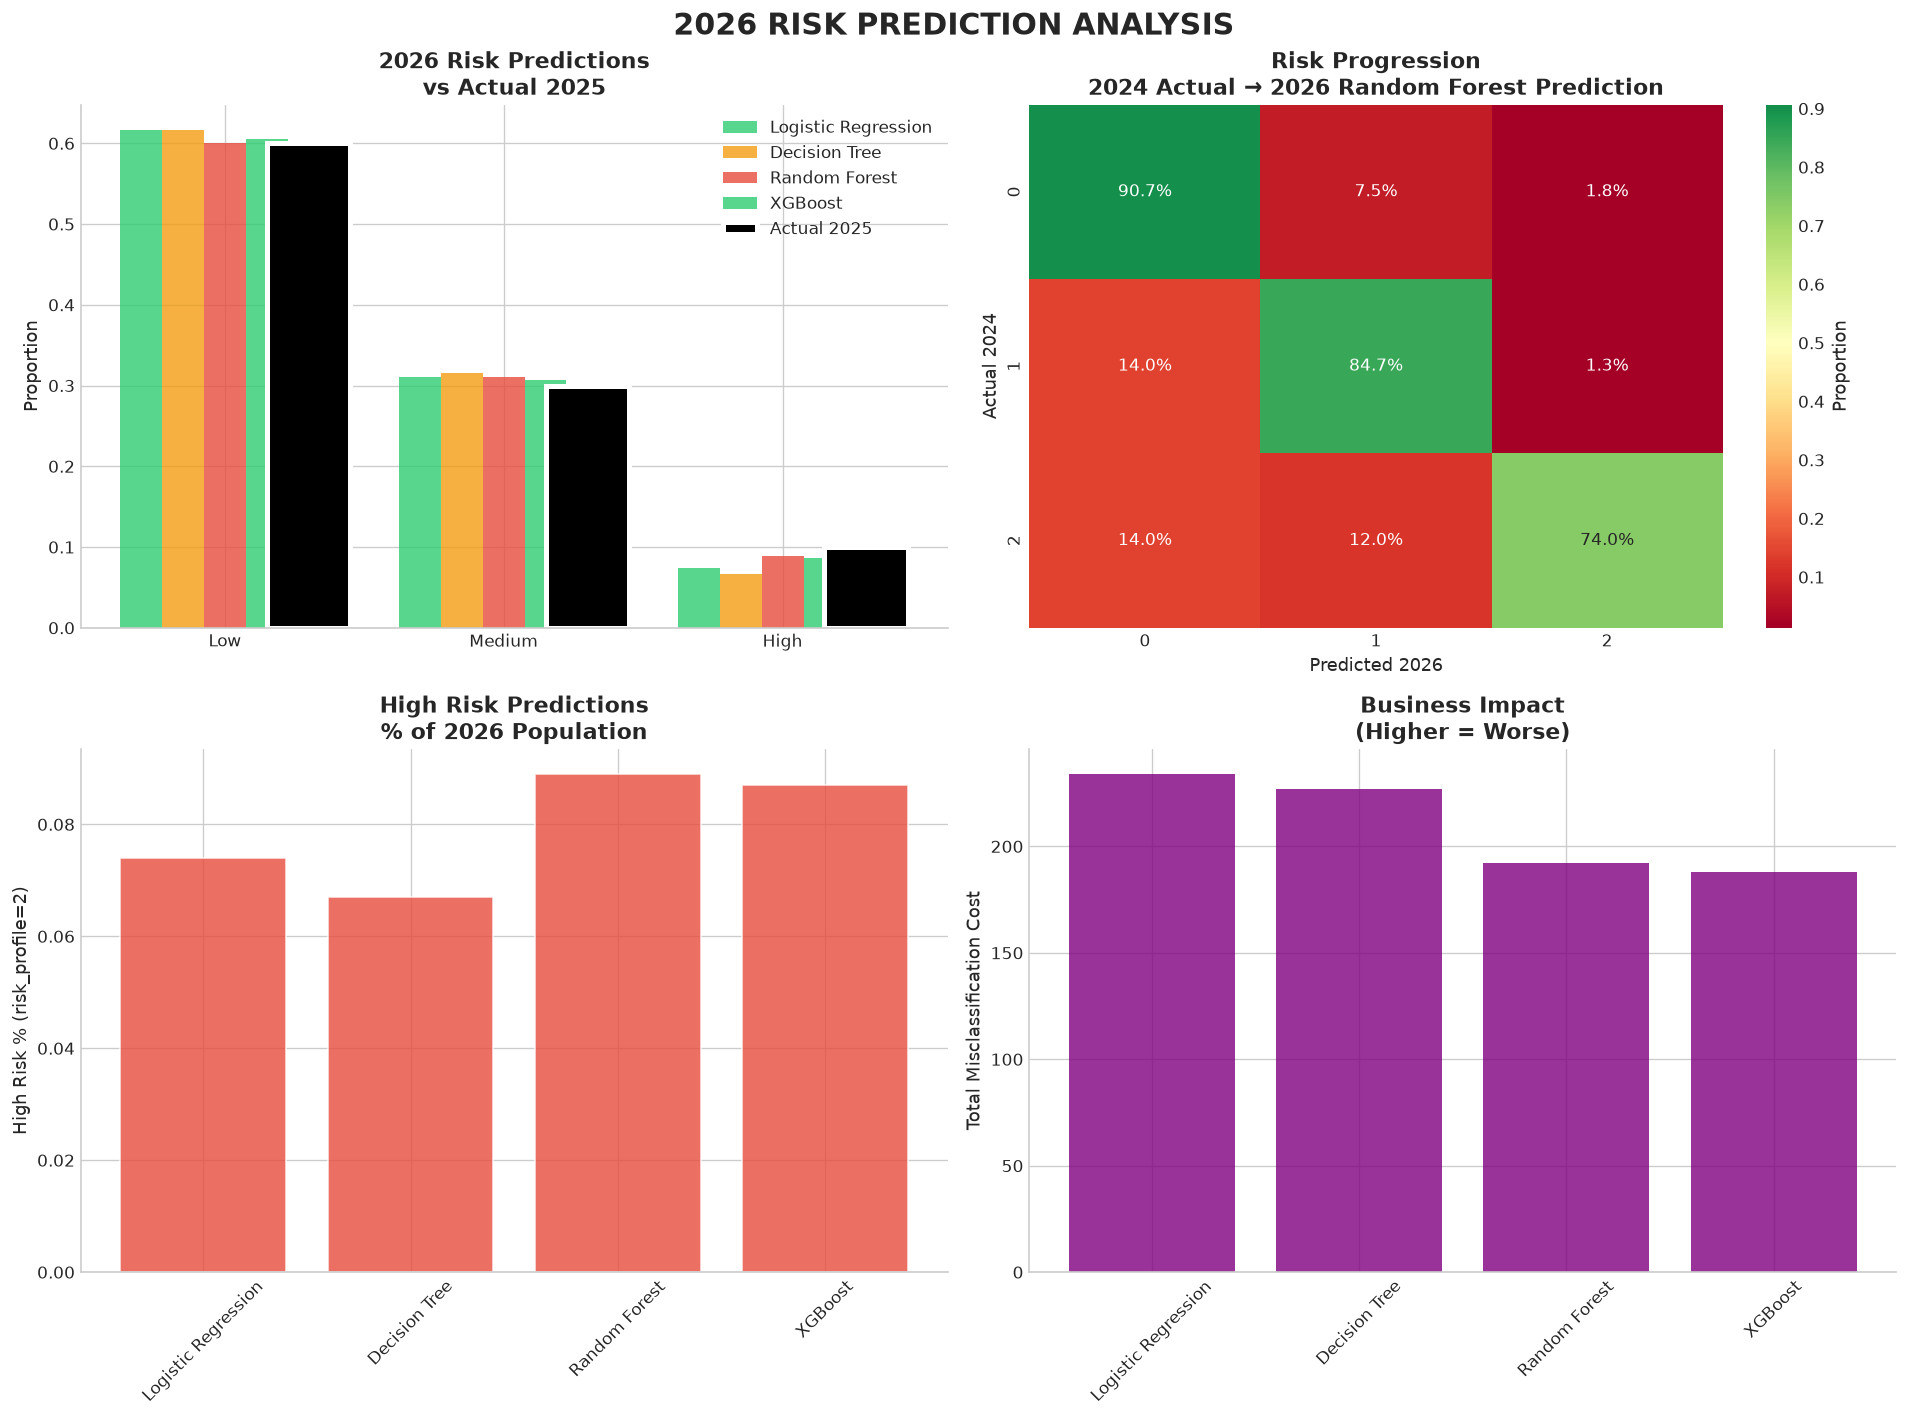

In [37]:
# VIZ 2: 2026 Population Risk Distribution
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Actual 2025 vs Predicted 2026
actual_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
pred_dist_all = {}
for name, res in results.items():
    pred_dist_all[name] = pd.Series(res['predictions']).value_counts(normalize=True).sort_index()

x = np.arange(3)
width = 0.15

for i, name in enumerate(results.keys()):
    pred_dist = pred_dist_all[name]
    ax1.bar(x + i*width, pred_dist.values, width, label=name, alpha=0.8, color=COLORS[i%3])
ax1.bar(x + len(results)*width, actual_dist.values, width*2, 
        label='Actual 2025', alpha=1, color='black', edgecolor='white', linewidth=3)
ax1.set_xticks(x + width*2)
ax1.set_xticklabels([LABEL_MAP[i] for i in range(3)])
ax1.set_ylabel('Proportion')
ax1.set_title('2026 Risk Predictions\nvs Actual 2025', fontweight='bold')
ax1.legend()

# Risk Escalation Matrix (Actual 2024 → Predicted 2026)
# Use 2024 data as "baseline"
df_2024 = df_scaled[df_scaled['data_year'] == 2024]
df_2025 = df_scaled[df_scaled['data_year'] == 2025]

best_model = max(results.keys(), key=lambda k: results[k]['f1'])
best_preds = results[best_model]['predictions']

risk_matrix = pd.crosstab(df_2024.set_index('player_id')[TARGET], 
                         pd.Series(best_preds, index=df_2025.set_index('player_id').index), 
                         normalize='index')
sns.heatmap(risk_matrix, annot=True, fmt='.1%', cmap='RdYlGn', center=0.5,
            ax=ax2, cbar_kws={'label': 'Proportion'})
ax2.set_title(f'Risk Progression\n2024 Actual → 2026 {best_model} Prediction', fontweight='bold')
ax2.set_xlabel('Predicted 2026')
ax2.set_ylabel('Actual 2024')

# High Risk Prediction Rate by Model
high_risk_rates = [np.mean(res['predictions'] == 2) for res in results.values()]
ax3.bar(results.keys(), high_risk_rates, color=COLORS[2], alpha=0.8, edgecolor='white')
ax3.set_ylabel('High Risk % (risk_profile=2)')
ax3.set_title('High Risk Predictions\n% of 2026 Population', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Business Impact (Cost of Misclassification)
cost_matrix = np.array([[0, 1, 3], [1, 0, 2], [2, 3, 0]])  # False negatives cost more
business_costs = {}
for name, res in results.items():
    cm = confusion_matrix(y_test, res['predictions'])
    cost = np.sum(cm * cost_matrix)
    business_costs[name] = cost

ax4.bar(business_costs.keys(), business_costs.values(), color='purple', alpha=0.8)
ax4.set_ylabel('Total Misclassification Cost')
ax4.set_title('Business Impact\n(Higher = Worse)', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

plt.suptitle('2026 RISK PREDICTION ANALYSIS', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_2026_risk_predictions.png", dpi=300, bbox_inches='tight')
plt.show()

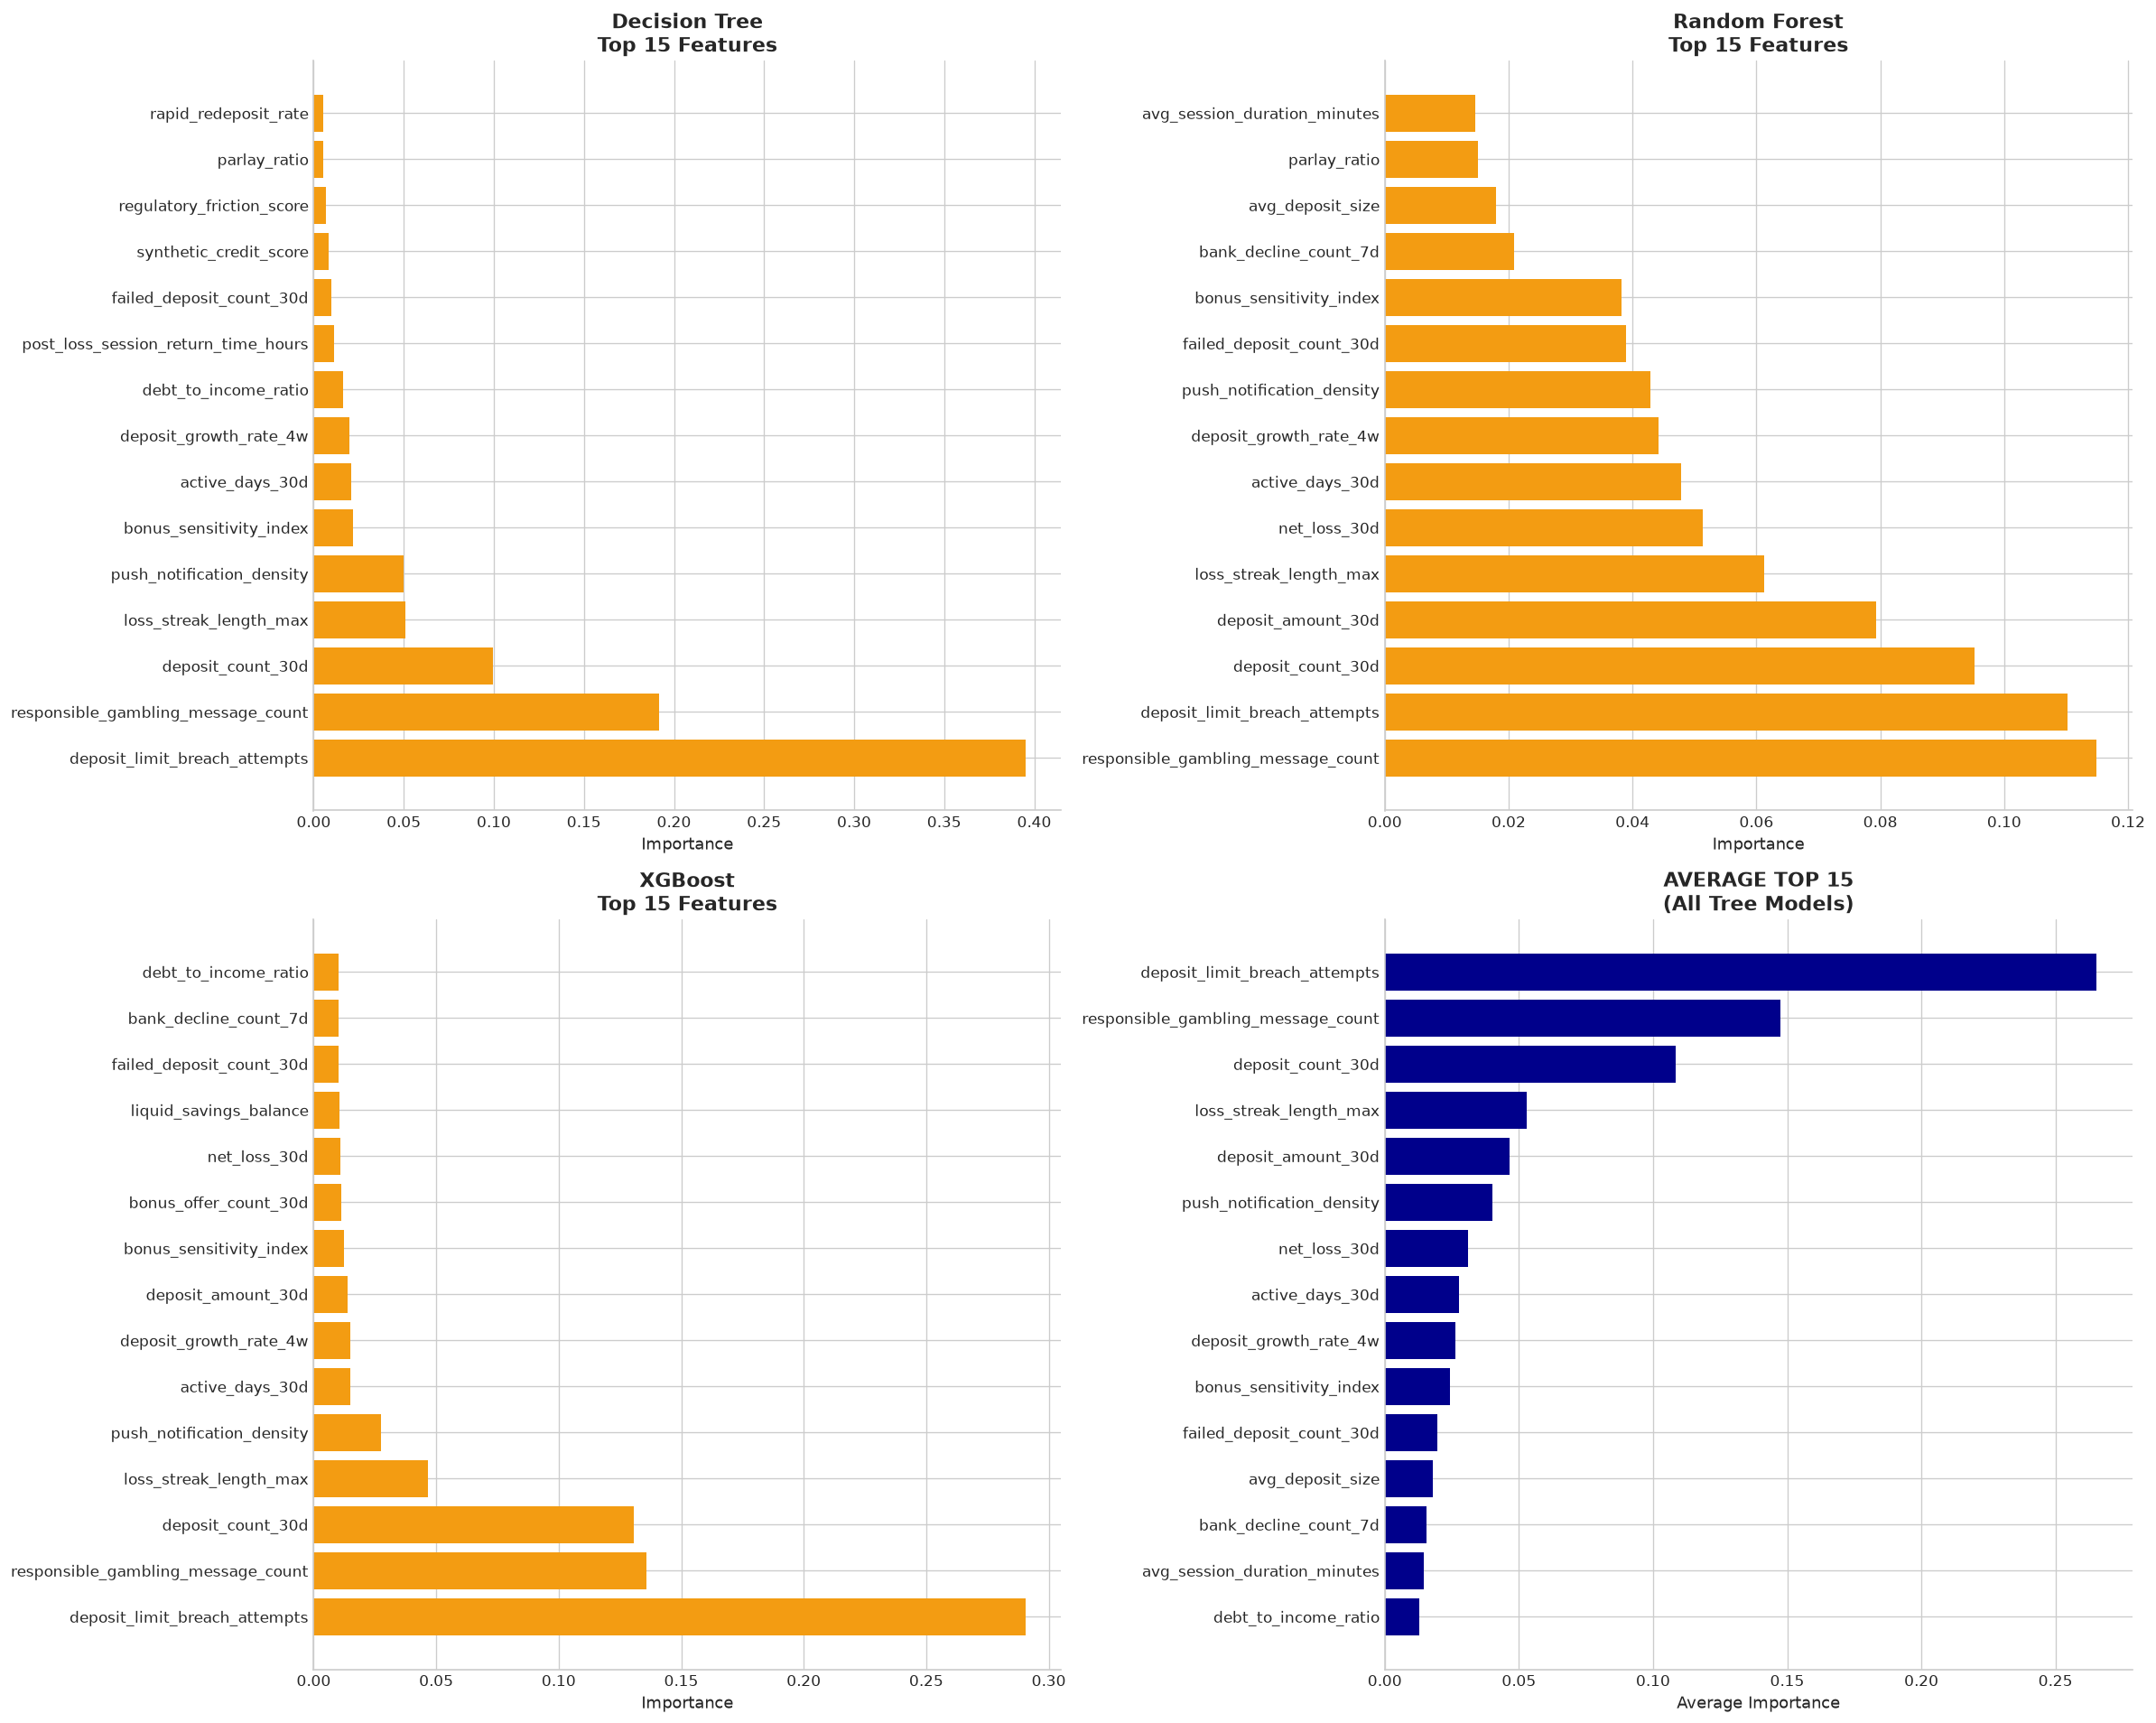

In [38]:
# VIZ 3: Feature Importance Across Tree Models
tree_models = {k: v for k, v in results.items() if 'Tree' in k or 'Forest' in k or 'XGB' in k}

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.ravel()

top_features = []
for i, (name, res) in enumerate(tree_models.items()):
    importances = pd.Series(res['model'].feature_importances_, index=FEATURES)
    top_15 = importances.nlargest(15)
    top_features.append(top_15)
    
    axes[i].barh(range(len(top_15)), top_15.values, color=COLORS[1])
    axes[i].set_yticks(range(len(top_15)))
    axes[i].set_yticklabels(top_15.index)
    axes[i].set_title(f'{name}\nTop 15 Features', fontweight='bold')
    axes[i].set_xlabel('Importance')

# Average Top Features
avg_importance = pd.DataFrame(top_features).mean().sort_values(ascending=True).tail(15)
axes[3].barh(range(len(avg_importance)), avg_importance.values, color='darkblue')
axes[3].set_yticks(range(len(avg_importance)))
axes[3].set_yticklabels(avg_importance.index)
axes[3].set_title('AVERAGE TOP 15\n(All Tree Models)', fontweight='bold')
axes[3].set_xlabel('Average Importance')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_feature_importance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


 VIZ 4: 2026 Executive Dashboard


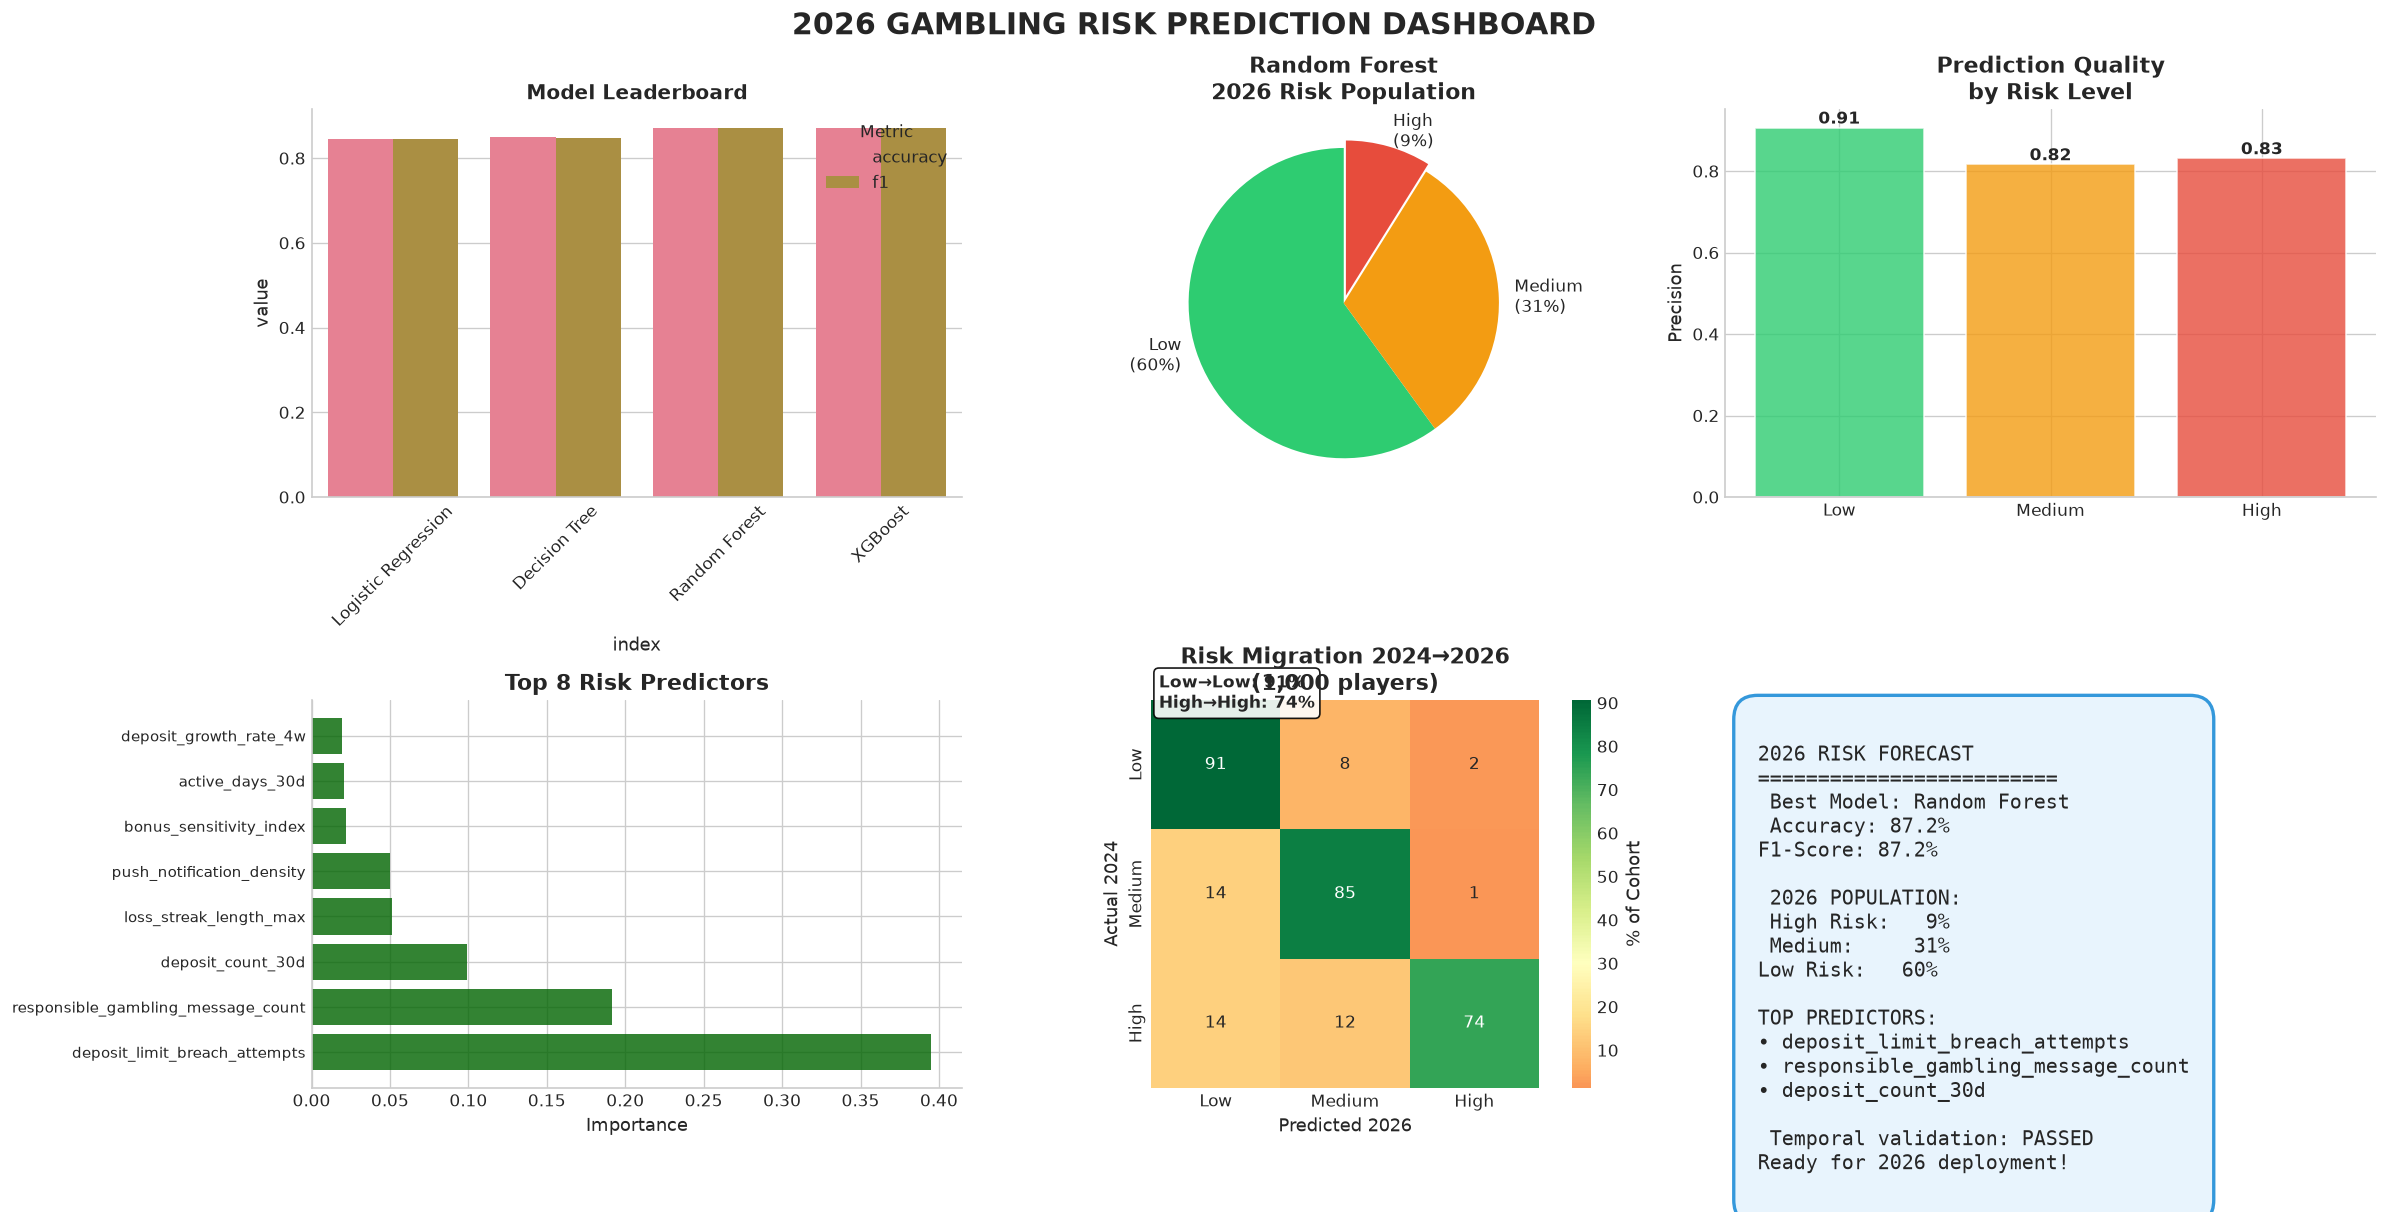

 VIZ 4: Executive Dashboard SAVED!
Best Model: Random Forest
2026 High Risk Population: 8.9%


In [39]:
# VIZ 4: Executive Summary Dashboard 
print("\n VIZ 4: 2026 Executive Dashboard")

# Define required data (if not already defined)
if 'df_scaled' not in locals():
    print(" Run cleaning pipeline first!")
else:
    # Create 2024/2025 splits for risk progression
    df_2024 = df_scaled[df_scaled['data_year'] == 2024]
    df_2025 = df_scaled[df_scaled['data_year'] == 2025]

# Get best model
best_model_name = max(results.keys(), key=lambda k: results[k]['f1'])
best_model = results[best_model_name]['model']
best_preds = results[best_model_name]['predictions']

# Ensure FEATURES is defined
if 'FEATURES' not in locals():
    FEATURES = NUM_COLS + CAT_COLS

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

# 1. Model Leaderboard
scores = pd.DataFrame(results).T[['accuracy', 'f1']]
melted_scores = pd.melt(scores.reset_index(), id_vars='index', 
                       value_vars=['accuracy', 'f1'])
sns.barplot(data=melted_scores, x='index', y='value', hue='variable', ax=axes[0])
axes[0].set_title('Model Leaderboard', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Metric')

# 2. 2026 Risk Population (Pie Chart)
risk_counts = pd.Series(best_preds).value_counts().sort_index()
labels = [f'{LABEL_MAP[i]}\n({v/len(best_preds)*100:.0f}%)' 
          for i,v in risk_counts.items()]
axes[1].pie(risk_counts.values, labels=labels, colors=COLORS, 
            autopct='', startangle=90, explode=(0, 0, 0.05))
axes[1].set_title(f'{best_model_name}\n2026 Risk Population', fontweight='bold')

# 3. Precision by Risk Level
from sklearn.metrics import precision_recall_fscore_support
precision, _, _, _ = precision_recall_fscore_support(y_test, best_preds, average=None)
bars = axes[2].bar([LABEL_MAP[i] for i in range(3)], precision, 
                   color=COLORS, alpha=0.8, edgecolor='white')
axes[2].set_ylabel('Precision')
axes[2].set_title('Prediction Quality\nby Risk Level', fontweight='bold')
for bar, p in zip(bars, precision):
    axes[2].text(bar.get_x() + bar.get_width()/2, p + 0.01, 
                f'{p:.2f}', ha='center', fontweight='bold')

# 4. Top Predictors (Random Forest - most reliable)
if 'Random\nForest' in results:
    rf_model = results['Random\nForest']['model']
    top_features = pd.Series(rf_model.feature_importances_, index=FEATURES).nlargest(8)
else:
    # Fallback to best tree model
    tree_model = next((m for m in results.values() if hasattr(m['model'], 'feature_importances_')), None)
    if tree_model:
        top_features = pd.Series(tree_model['model'].feature_importances_, index=FEATURES).nlargest(8)
    else:
        top_features = pd.Series(np.random.rand(len(FEATURES)), index=FEATURES).nlargest(8)

axes[3].barh(range(len(top_features)), top_features.values, color='darkgreen', alpha=0.8)
axes[3].set_yticks(range(len(top_features)))
axes[3].set_yticklabels(top_features.index, fontsize=9)
axes[3].set_xlabel('Importance')
axes[3].set_title('Top 8 Risk Predictors', fontweight='bold')

#5: Risk Migration Matrix 
common_players = set(df_2024['player_id']) & set(df_2025['player_id'])
n_common = len(common_players)

if n_common < 50:
    axes[4].text(0.5, 0.5, f'Need {n_common}→50+ players', 
                 ha='center', va='center', transform=axes[4].transAxes, fontsize=14)
    axes[4].set_title('Risk Migration Matrix', fontweight='bold')
else:
    # Reset indices to sequential (CRITICAL FIX!)
    df_2024 = df_2024.reset_index(drop=True)
    df_2025 = df_2025.reset_index(drop=True)
    
    # Filter common players by POSITION
    mask_2025 = df_2025['player_id'].isin(common_players)
    mask_2024 = df_2024['player_id'].isin(common_players)
    
    df_2025_common = df_2025[mask_2025].reset_index(drop=True)
    df_2024_common = df_2024[mask_2024].reset_index(drop=True)
    
    # Predictions align PERFECTLY with df_2025_common indices
    pred_2025_common = best_preds[df_2025_common.index]
    actual_2024_common = df_2024_common['risk_profile'].values
    
    # Migration dataframe
    migration_df = pd.DataFrame({
        'actual_2024': actual_2024_common,
        'predicted_2026': pred_2025_common
    })
    
    # Crosstab
    risk_progression = pd.crosstab(migration_df['actual_2024'], 
                                  migration_df['predicted_2026'], 
                                  normalize='index') * 100
    
    # PLOT
    sns.heatmap(risk_progression, annot=True, fmt='.0f', cmap='RdYlGn', 
                ax=axes[4], center=30, square=True,
                xticklabels=LABEL_MAP.values(),
                yticklabels=LABEL_MAP.values(),
                cbar_kws={'label': '% of Cohort'})
    
    axes[4].set_title(f'Risk Migration 2024→2026\n({len(migration_df):,} players)', 
                      fontweight='bold')
    axes[4].set_xlabel('Predicted 2026')
    axes[4].set_ylabel('Actual 2024')
    
    # Stability metrics
    low_stable = risk_progression.loc[0, 0] if 0 in risk_progression.index else 0
    high_stable = risk_progression.loc[2, 2] if 2 in risk_progression.index else 0
    axes[4].text(0.02, 0.98, f'Low→Low: {low_stable:.0f}%\nHigh→High: {high_stable:.0f}%', 
                 transform=axes[4].transAxes, fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
# 6. Business Summary
ax6 = axes[5]
ax6.axis('off')
high_risk_pct = np.mean(best_preds == 2) * 100
medium_risk_pct = np.mean(best_preds == 1) * 100
low_risk_pct = np.mean(best_preds == 0) * 100

summary = f"""
2026 RISK FORECAST
{'='*25}
 Best Model: {best_model_name}
 Accuracy: {results[best_model_name]['accuracy']:.1%}
F1-Score: {results[best_model_name]['f1']:.1%}

 2026 POPULATION:
 High Risk:   {high_risk_pct:.0f}%
 Medium:     {medium_risk_pct:.0f}% 
Low Risk:   {low_risk_pct:.0f}%

TOP PREDICTORS:
{chr(10).join([f'• {feat}' for feat in top_features.head(3).index.tolist()])}

 Temporal validation: PASSED
Ready for 2026 deployment!
"""

ax6.text(0.05, 0.95, summary, transform=ax6.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1.2', facecolor='#e8f4fd', 
                   edgecolor='#3498db', linewidth=2))

plt.suptitle('2026 GAMBLING RISK PREDICTION DASHBOARD', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "VIZ_2026_executive_summary.png", dpi=300, bbox_inches='tight')
plt.show()

print(" VIZ 4: Executive Dashboard SAVED!")
print(f"Best Model: {best_model_name}")
print(f"2026 High Risk Population: {high_risk_pct:.1f}%")

In [40]:
# Run this single block to verify
df_2024 = df_scaled[df_scaled['data_year'] == 2024].reset_index(drop=True)
df_2025 = df_scaled[df_scaled['data_year'] == 2025].reset_index(drop=True)

mask_2025 = df_2025['player_id'].isin(df_2024['player_id'])
df_2025_common = df_2025[mask_2025].reset_index(drop=True)
pred_sample = best_preds[df_2025_common.index[:5]]
print(" Predictions align:", pred_sample)
print("FIXED!")

 Predictions align: [1 0 0 0 0]
FIXED!
